In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# New imports for modeling
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load Stage 3 output
df = pd.read_parquet("../data/aapl_stage3_features.parquet")
print(f"Loaded: {df.shape}")

Loaded: (400391, 78)


In [2]:
# Step 1a: Look 50 events into the future
HORIZON = 50

df["future_mid"] = df["mid_price"].shift(-HORIZON)
df["price_change"] = df["future_mid"] - df["mid_price"]

# Step 1b: Set the threshold = half the median spread
threshold = df["spread"].median() / 2
print(f"Threshold for 'real' price move: ${threshold:.4f}")




Threshold for 'real' price move: $0.0750


In [3]:
# Use a smaller threshold so up/down classes have more examples
threshold = df["spread"].median() * 0.15   # one-fifth of the median spread instead of half
print(f"New threshold: ${threshold:.4f}")

New threshold: $0.0225


In [4]:
# Step 1c: Create the label
# 1 = up, -1 = down, 0 = flat
df["label"] = 0
df.loc[df["price_change"] > threshold, "label"] = 1
df.loc[df["price_change"] < -threshold, "label"] = -1

# Step 1d: Drop rows where future_mid is NaN (last 50 rows)
df = df.dropna(subset=["future_mid"])

print(f"\nLabel distribution:")
print(df["label"].value_counts())
print(f"\nLabel percentages:")
print(df["label"].value_counts(normalize=True) * 100)


Label distribution:
label
 0    155007
-1    126626
 1    118708
Name: count, dtype: int64

Label percentages:
label
 0    38.718742
-1    31.629536
 1    29.651722
Name: proportion, dtype: float64


In [5]:
# Re-define the exclude list, now also dropping mid_price
exclude_cols = [
    "time_sec", "time_hour", 
    "future_mid", "price_change", "label",
    "mid_price",          # ← NEW: drop the absolute price level (leakage)
    "microprice",         # ← ALSO drop: it's just mid_price ± small adjustment, same leakage risk
]
exclude_cols += [c for c in df.columns if c.startswith("ask_price_") or c.startswith("bid_price_")]
exclude_cols += [c for c in df.columns if c.startswith("ask_size_") or c.startswith("bid_size_")]

feature_cols = [c for c in df.columns if c not in exclude_cols]

print(f"Number of features: {len(feature_cols)}")
# Should now be 34 (was 36)
print(f"\nFeature names:")
for c in feature_cols:
    print(f"  - {c}")

Number of features: 34

Feature names:
  - spread
  - ofi_top
  - ofi_deep
  - total_bid_size
  - total_ask_size
  - log_spread
  - bid_volume_top
  - ask_volume_top
  - total_volume_top
  - ofi_weighted
  - ofi_level_1
  - ofi_level_3
  - ofi_level_5
  - micro_minus_mid
  - ofi_top_roll_50
  - ofi_top_roll_200
  - mid_volatility_50
  - mid_volatility_200
  - spread_roll_50
  - mid_change_50
  - mid_change_200
  - ask_gap_1to2
  - bid_gap_1to2
  - ask_gap_1to5
  - bid_gap_1to5
  - volume_imbalance_5
  - new_orders_last_50
  - cancels_last_50
  - executions_last_50
  - buy_events_last_50
  - sell_events_last_50
  - buy_sell_ratio_50
  - time_delta
  - event_rate_50


In [6]:
n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

print(f"Train: {len(train_df):,} rows ({len(train_df)/n*100:.1f}%)")
print(f"Val:   {len(val_df):,} rows ({len(val_df)/n*100:.1f}%)")
print(f"Test:  {len(test_df):,} rows ({len(test_df)/n*100:.1f}%)")

# Confirm they don't overlap and cover everything
print(f"\nTotal: {len(train_df) + len(val_df) + len(test_df):,}")
print(f"Original: {n:,}")

Train: 280,238 rows (70.0%)
Val:   60,051 rows (15.0%)
Test:  60,052 rows (15.0%)

Total: 400,341
Original: 400,341


In [7]:
X_train = train_df[feature_cols]
y_train = train_df["label"]

X_val = val_df[feature_cols]
y_val = val_df["label"]

X_test = test_df[feature_cols]
y_test = test_df["label"]

print(f"X_train shape: {X_train.shape}")
print(f"y_train distribution: {dict(y_train.value_counts())}")
print(f"y_val distribution:   {dict(y_val.value_counts())}")
print(f"y_test distribution:  {dict(y_test.value_counts())}")

X_train shape: (280238, 34)
y_train distribution: {0: np.int64(102864), -1: np.int64(90856), 1: np.int64(86518)}
y_val distribution:   {0: np.int64(24661), -1: np.int64(18239), 1: np.int64(17151)}
y_test distribution:  {0: np.int64(27482), -1: np.int64(17531), 1: np.int64(15039)}


In [8]:
# LightGBM expects labels starting at 0
# Map: -1 → 0 (down), 0 → 1 (flat), 1 → 2 (up)
label_map = {-1: 0, 0: 1, 1: 2}
label_unmap = {0: -1, 1: 0, 2: 1}

y_train_mapped = y_train.map(label_map)
y_val_mapped = y_val.map(label_map)
y_test_mapped = y_test.map(label_map)

print("Label mapping: -1 (down) → 0, 0 (flat) → 1, 1 (up) → 2")
print(f"\nTraining target distribution after mapping: {dict(y_train_mapped.value_counts())}")

Label mapping: -1 (down) → 0, 0 (flat) → 1, 1 (up) → 2

Training target distribution after mapping: {1: np.int64(102864), 0: np.int64(90856), 2: np.int64(86518)}


In [9]:
model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=15,
    max_depth=6,
    objective="multiclass",
    num_class=3,
    class_weight="balanced",
    min_child_samples=100,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

print("Re-training with leakage features removed...")
model.fit(
    X_train, y_train_mapped,
    eval_set=[(X_val, y_val_mapped)],
    callbacks=[lgb.early_stopping(stopping_rounds=20)],
)
print(f"✅ Best iteration: {model.best_iteration_}")

Re-training with leakage features removed...
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[248]	valid_0's multi_logloss: 1.02525
✅ Best iteration: 248


In [10]:
from sklearn.metrics import f1_score
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

val_accuracy = accuracy_score(y_val_mapped, y_val_pred)
test_accuracy = accuracy_score(y_test_mapped, y_test_pred)
macro_f1_val = f1_score(y_val_mapped, y_val_pred, average="macro")
macro_f1_test = f1_score(y_test_mapped, y_test_pred, average="macro")

print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy:       {test_accuracy*100:.2f}%")
print(f"Validation macro F1: {macro_f1_val:.4f}")
print(f"Test macro F1:       {macro_f1_test:.4f}")
print()
print(classification_report(y_test_mapped, y_test_pred, target_names=["DOWN", "FLAT", "UP"]))

Validation accuracy: 47.16%
Test accuracy:       43.34%
Validation macro F1: 0.4649
Test macro F1:       0.4105

              precision    recall  f1-score   support

        DOWN       0.38      0.38      0.38     17531
        FLAT       0.49      0.53      0.51     27482
          UP       0.38      0.31      0.34     15039

    accuracy                           0.43     60052
   macro avg       0.42      0.41      0.41     60052
weighted avg       0.43      0.43      0.43     60052



In [11]:
# Look at per-class performance with classification_report
print("\nDetailed performance on test set:")
print(classification_report(
    y_test_mapped, y_test_pred, 
    target_names=["DOWN", "FLAT", "UP"]
))


Detailed performance on test set:
              precision    recall  f1-score   support

        DOWN       0.38      0.38      0.38     17531
        FLAT       0.49      0.53      0.51     27482
          UP       0.38      0.31      0.34     15039

    accuracy                           0.43     60052
   macro avg       0.42      0.41      0.41     60052
weighted avg       0.43      0.43      0.43     60052



In [12]:
import pickle

with open("../data/lgb_model_improved.pkl", "wb") as f:
    pickle.dump({
        "model": model,
        "feature_cols": feature_cols,
        "label_map": label_map,
        "label_unmap": label_unmap,
        "val_accuracy": val_accuracy,
        "test_accuracy": test_accuracy,
        "val_macro_f1": macro_f1_val,
        "test_macro_f1": macro_f1_test,
        "threshold": 0.0225,
        "horizon": 50,
        "baseline_flat_f1": 0.2093,
        "baseline_random_f1": 0.3318,
    }, f)

print("✅ Final model saved with all metrics")

✅ Final model saved with all metrics


In [13]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score

# Baseline 1: Always predict FLAT (majority class)
baseline_majority = DummyClassifier(strategy="most_frequent")
baseline_majority.fit(X_train, y_train_mapped)
baseline_f1 = f1_score(y_test_mapped, baseline_majority.predict(X_test), average="macro")

# Baseline 2: Predict randomly with class probabilities
baseline_random = DummyClassifier(strategy="stratified", random_state=42)
baseline_random.fit(X_train, y_train_mapped)
baseline_random_f1 = f1_score(y_test_mapped, baseline_random.predict(X_test), average="macro")

print(f"Always-FLAT baseline:   macro F1 = {baseline_f1:.4f}")
print(f"Random baseline:        macro F1 = {baseline_random_f1:.4f}")
print(f"Your LightGBM model:    macro F1 = {macro_f1_test:.4f}")
print(f"\nLift over best baseline: {macro_f1_test - max(baseline_f1, baseline_random_f1):.4f}")

Always-FLAT baseline:   macro F1 = 0.2093
Random baseline:        macro F1 = 0.3318
Your LightGBM model:    macro F1 = 0.4105

Lift over best baseline: 0.0786


In [14]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


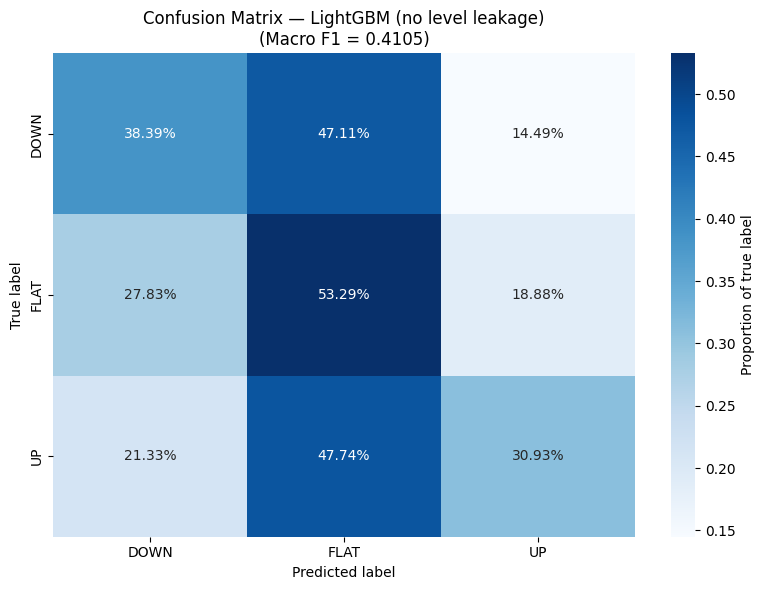

In [15]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
# Update filenames so we don't overwrite the old plots
cm = confusion_matrix(y_test_mapped, y_test_pred)
cm_normalized = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt=".2%", cmap="Blues",
            xticklabels=["DOWN", "FLAT", "UP"], yticklabels=["DOWN", "FLAT", "UP"],
            cbar_kws={"label": "Proportion of true label"})
plt.title(f"Confusion Matrix — LightGBM (no level leakage)\n(Macro F1 = {macro_f1_test:.4f})")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.savefig("../outputs/06_confusion_matrix_improved.png", dpi=150, bbox_inches="tight")
plt.show()

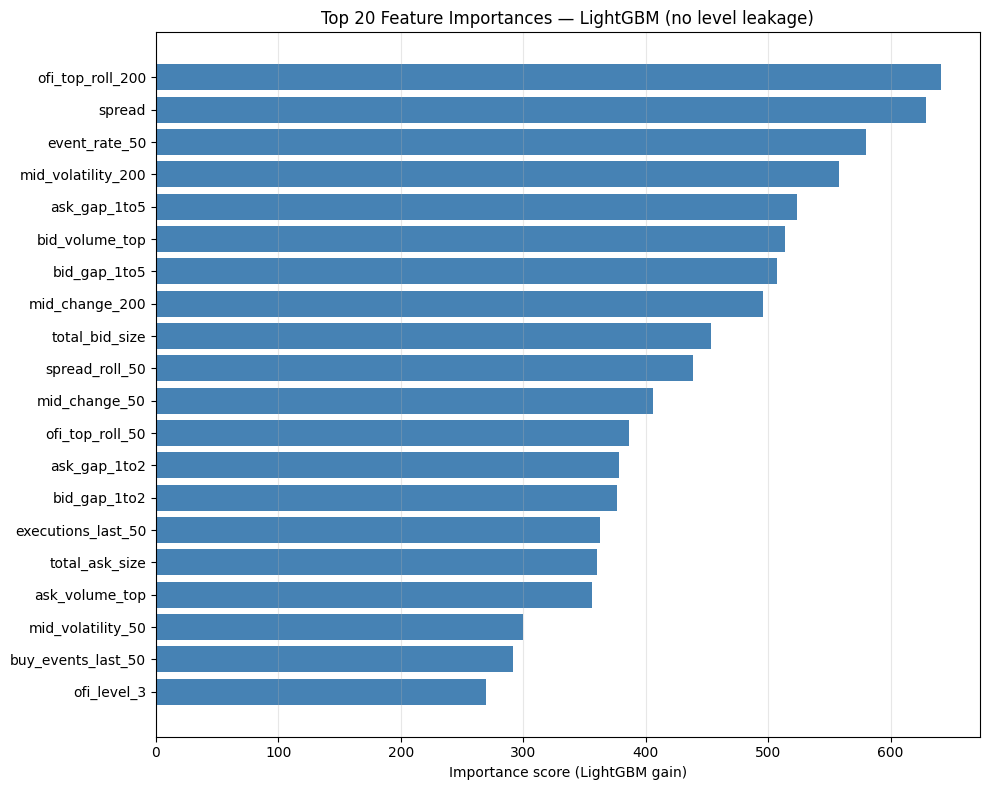


Top 10 features (no leakage):
           feature  importance
  ofi_top_roll_200         641
            spread         629
     event_rate_50         580
mid_volatility_200         558
      ask_gap_1to5         524
    bid_volume_top         514
      bid_gap_1to5         507
    mid_change_200         496
    total_bid_size         453
    spread_roll_50         439


In [16]:

# New feature importance
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=True)

top_20 = importance_df.tail(20)
plt.figure(figsize=(10, 8))
plt.barh(top_20["feature"], top_20["importance"], color="steelblue")
plt.title("Top 20 Feature Importances — LightGBM (no level leakage)")
plt.xlabel("Importance score (LightGBM gain)")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/07_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 10 features (no leakage):")
print(importance_df.tail(10).iloc[::-1].to_string(index=False))

In [17]:
import pickle

with open("../data/lgb_model_final.pkl", "wb") as f:
    pickle.dump({
        "model": model,
        "feature_cols": feature_cols,
        "label_map": label_map,
        "label_unmap": label_unmap,
        "val_accuracy": 0.4716,
        "test_accuracy": 0.4334,
        "val_macro_f1": 0.4649,
        "test_macro_f1": 0.4105,
        "threshold": 0.0225,
        "horizon": 50,
        "baseline_flat_f1": 0.2093,
        "baseline_random_f1": 0.3318,
        "lift_over_random": 0.0786,
        "n_features": 34,
    }, f)

print("✅ Final model saved")

✅ Final model saved


In [18]:
# We'll simulate this trading rule on the test set:
# - If model predicts UP with probability > 0.40, "buy" at the ask, "sell" at the next mid 50 events later
# - If model predicts DOWN with probability > 0.40, "sell" (short) at the bid, "cover" at next mid 50 events later
# - Otherwise, no trade
# - Each trade costs the half-spread (the trader crosses the spread)

# Get probability predictions
y_test_proba = model.predict_proba(X_test)

# Get real prices from the test split (we'll need ask, bid, mid for backtest)
test_df_reset = test_df.reset_index(drop=True)
test_df_reset["pred_proba_down"] = y_test_proba[:, 0]
test_df_reset["pred_proba_flat"] = y_test_proba[:, 1]
test_df_reset["pred_proba_up"] = y_test_proba[:, 2]

print(test_df_reset[["mid_price", "ask_price_1", "bid_price_1", "pred_proba_down", "pred_proba_flat", "pred_proba_up"]].head())

   mid_price  ask_price_1  bid_price_1  pred_proba_down  pred_proba_flat  \
0    580.085       580.13       580.04         0.465938         0.237411   
1    580.085       580.13       580.04         0.464876         0.236870   
2    580.085       580.13       580.04         0.464452         0.237567   
3    580.085       580.13       580.04         0.464876         0.236870   
4    580.085       580.13       580.04         0.464876         0.236870   

   pred_proba_up  
0       0.296651  
1       0.298254  
2       0.297981  
3       0.298254  
4       0.298254  


In [19]:
# Backtest logic
CONFIDENCE = 0.40    # only trade when prob > 0.40
HORIZON = 50         # exit position after 50 events

pnl_per_trade = []   # list of profits/losses per trade
position_log = []    # log each trade for analysis

for i in range(len(test_df_reset) - HORIZON):
    p_up = test_df_reset.loc[i, "pred_proba_up"]
    p_down = test_df_reset.loc[i, "pred_proba_down"]
    
    entry_ask = test_df_reset.loc[i, "ask_price_1"]
    entry_bid = test_df_reset.loc[i, "bid_price_1"]
    entry_mid = test_df_reset.loc[i, "mid_price"]
    
    exit_mid = test_df_reset.loc[i + HORIZON, "mid_price"]
    
    if p_up > CONFIDENCE:
        # Long trade: buy at ask, sell at future mid
        pnl = exit_mid - entry_ask
        position_log.append({"i": i, "side": "LONG", "entry": entry_ask, "exit": exit_mid, "pnl": pnl})
        pnl_per_trade.append(pnl)
    elif p_down > CONFIDENCE:
        # Short trade: sell at bid, cover at future mid
        pnl = entry_bid - exit_mid
        position_log.append({"i": i, "side": "SHORT", "entry": entry_bid, "exit": exit_mid, "pnl": pnl})
        pnl_per_trade.append(pnl)

pnl_array = np.array(pnl_per_trade)
n_trades = len(pnl_array)
total_pnl = pnl_array.sum()
mean_pnl = pnl_array.mean()
hit_rate = (pnl_array > 0).mean()
sharpe_per_trade = pnl_array.mean() / pnl_array.std()

print(f"Number of trades:  {n_trades:,}")
print(f"Total P&L:         ${total_pnl:,.2f}")
print(f"Mean P&L/trade:    ${mean_pnl:.4f}")
print(f"Hit rate:          {hit_rate*100:.2f}%")
print(f"Per-trade Sharpe:  {sharpe_per_trade:.4f}")

Number of trades:  22,020
Total P&L:         $-713.85
Mean P&L/trade:    $-0.0324
Hit rate:          21.86%
Per-trade Sharpe:  -0.7011


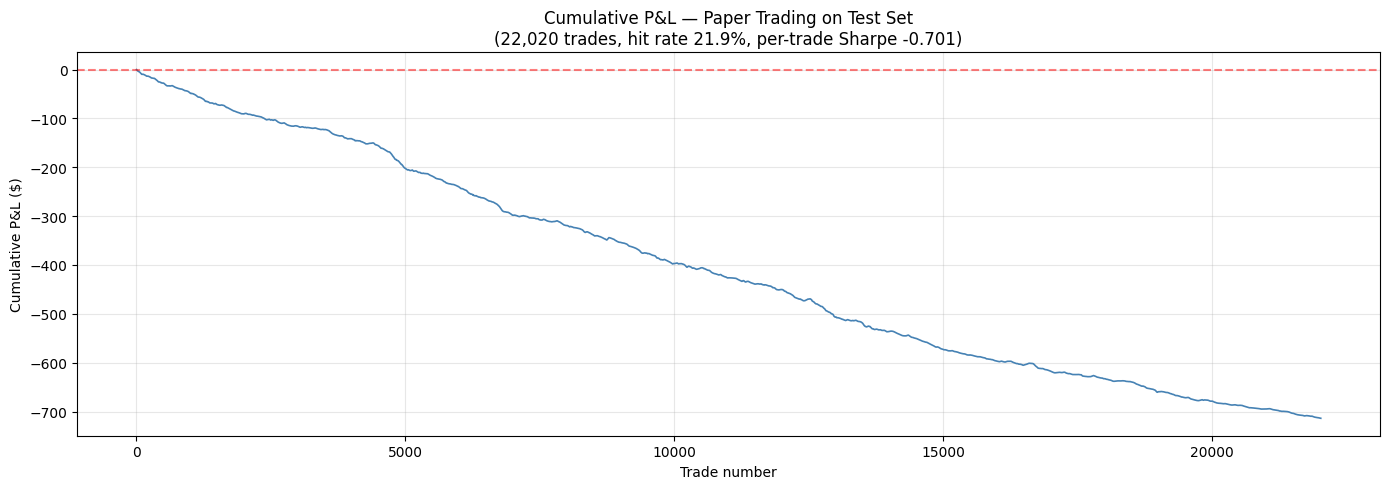

In [20]:
cumulative_pnl = np.cumsum(pnl_array)

plt.figure(figsize=(14, 5))
plt.plot(cumulative_pnl, color="steelblue", linewidth=1.2)
plt.title("Cumulative P&L — Paper Trading on Test Set\n"
          f"({n_trades:,} trades, hit rate {hit_rate*100:.1f}%, per-trade Sharpe {sharpe_per_trade:.3f})")
plt.xlabel("Trade number")
plt.ylabel("Cumulative P&L ($)")
plt.axhline(0, color="red", linestyle="--", alpha=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/09_pnl_curve.png", dpi=150, bbox_inches="tight")
plt.show()

In [21]:
# Re-run backtest WITHOUT crossing the spread (enter at mid, exit at mid)
# This isolates the signal quality from transaction costs.

pnl_no_costs = []
for i in range(len(test_df_reset) - HORIZON):
    p_up = test_df_reset.loc[i, "pred_proba_up"]
    p_down = test_df_reset.loc[i, "pred_proba_down"]
    
    entry_mid = test_df_reset.loc[i, "mid_price"]
    exit_mid = test_df_reset.loc[i + HORIZON, "mid_price"]
    
    if p_up > CONFIDENCE:
        pnl_no_costs.append(exit_mid - entry_mid)
    elif p_down > CONFIDENCE:
        pnl_no_costs.append(entry_mid - exit_mid)

pnl_no_costs = np.array(pnl_no_costs)
print(f"Trades (no costs):     {len(pnl_no_costs):,}")
print(f"Total P&L (no costs):  ${pnl_no_costs.sum():,.2f}")
print(f"Mean P&L (no costs):   ${pnl_no_costs.mean():.4f}")
print(f"Hit rate (no costs):   {(pnl_no_costs > 0).mean()*100:.2f}%")
print(f"Sharpe (no costs):     {pnl_no_costs.mean()/pnl_no_costs.std():.4f}")
print()
print(f"Cost of spread per trade: ${(pnl_no_costs.mean() - pnl_array.mean()):.4f}")


Trades (no costs):     22,020
Total P&L (no costs):  $308.94
Mean P&L (no costs):   $0.0140
Hit rate (no costs):   61.91%
Sharpe (no costs):     0.3397

Cost of spread per trade: $0.0464


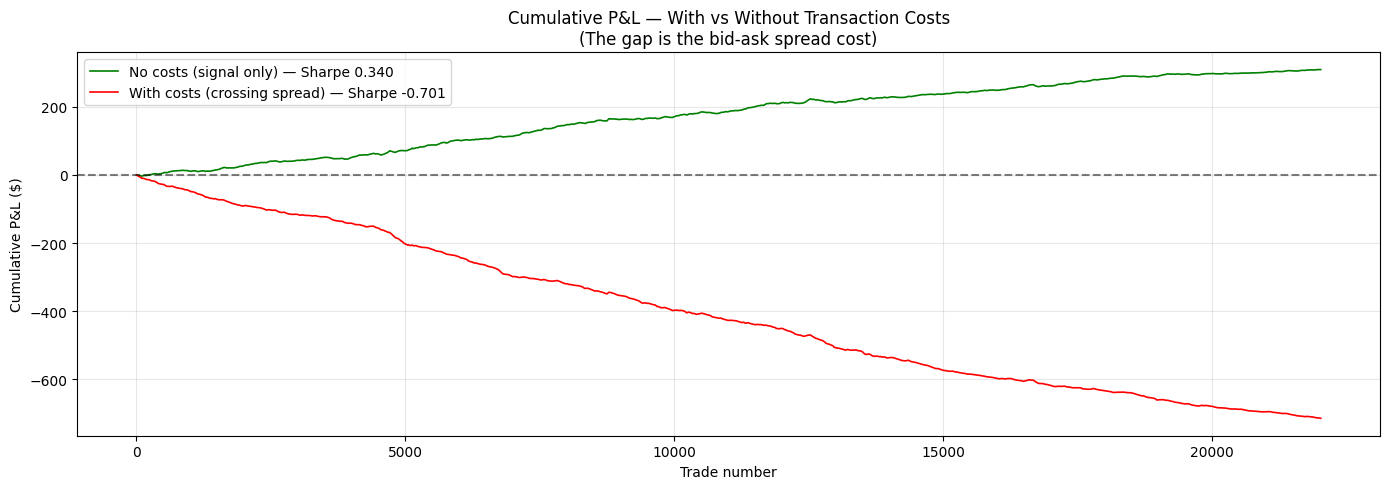

In [22]:
plt.figure(figsize=(14, 5))
plt.plot(np.cumsum(pnl_no_costs), color="green", linewidth=1.2, label=f"No costs (signal only) — Sharpe {pnl_no_costs.mean()/pnl_no_costs.std():.3f}")
plt.plot(np.cumsum(pnl_array), color="red", linewidth=1.2, label=f"With costs (crossing spread) — Sharpe {sharpe_per_trade:.3f}")
plt.title("Cumulative P&L — With vs Without Transaction Costs\n(The gap is the bid-ask spread cost)")
plt.xlabel("Trade number")
plt.ylabel("Cumulative P&L ($)")
plt.axhline(0, color="black", linestyle="--", alpha=0.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/10_pnl_with_vs_without_costs.png", dpi=150, bbox_inches="tight")
plt.show()